<a href="https://colab.research.google.com/github/whtan88/RandomDataAnalyst_Projects/blob/main/XGB_Classifier_Predict_Stock_Up_Down_p1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Run the below once first and restart

This is to install the pandas ta library which will be used for feature engineering

In [ ]:
# 1. Uninstall pandas_ta, numpy, and pandas to clean the environment.
!pip uninstall -y pandas_ta numpy pandas numba llvmlite

# 2. Install numpy, pandas, numba, and llvmlite versions compatible with Colab's pre-installed libraries.
# numpy 1.26.4 and pandas 2.2.2 are generally stable for Colab environments.
# numba 0.61.2 and llvmlite 0.44.0 are known to work with pandas_ta and potentially with numpy 1.x.
!pip install numpy==1.26.4 pandas==2.2.2 numba==0.61.2 llvmlite==0.44.0

# 3. Install pandas_ta, but prevent it from upgrading numpy, pandas, numba, or llvmlite again.
# Note: pandas_ta officially requires numpy>=2.2.6. If this version of pandas_ta
# does not work with numpy 1.x, you might need to find an older version of pandas_ta.
!pip install pandas_ta --no-deps

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: numba 0.60.0
Uninstalling numba-0.60.0:
  Successfully uninstalled numba-0.60.0
Found existing installation: llvmlite 0.43.0
Uninstalling llvmlite-0.43.0:
  Successfully uninstalled llvmlite-0.43.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 15.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 6.1 MB/s eta 0:00:00


# Run from here after Restarting Runtime from above

After re-running the installation, please **restart your Colab runtime** again (Runtime -> Restart runtime...) for these changes to take full effect.

In [ ]:
# Import libraries
import pandas_ta as ta

import re
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from datetime import datetime,timedelta
from sklearn.preprocessing import StandardScaler # This should now work
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

In [ ]:
# Function
def feature_engineering_1(df,ticker):
  # Insert Feature engineering here
  return df

def feature_engineering_2(df, ticker):
  # Insert Feature engineering here
  return df

def prep_data(ticker, start_date, test_start_date, current_date):

  def flatten_multiindex_columns(df_to_flatten):
      new_columns = []
      for col in df_to_flatten.columns:
          if isinstance(col, tuple):
              clean_parts = [str(part) for part in col if str(part).strip()]
              if clean_parts:
                  new_columns.append('_'.join(clean_parts))
              else:
                  if len(col) > 0 and str(col[0]).strip():
                      new_columns.append(str(col[0]))
                  else:
                      new_columns.append('_'.join(map(str, col)))
          else:
              new_columns.append(str(col))
      df_to_flatten.columns = new_columns
      return df_to_flatten

  df = yf.download(ticker, start=start_date, end=current_date, interval='1d', auto_adjust=True).reset_index()
  df = df.sort_index()
  df = feature_engineering_1(df,ticker)
  df = feature_engineering_2(df,ticker)

  # Drop rows with NaN values after feature engineering but before splitting
  #df.dropna(inplace=True)

  # Flatten columns after feature engineering
  df = flatten_multiindex_columns(df)

  # Corrected list_drop to match the actual DataFrame column names
  list_drop = ['target_close', ('Date',''), ('Close', ticker), ('High', ticker), ('Low', ticker), ('Open', ticker), ('Volume',ticker), 'cat_close', \
   ('SMA_5',''), ('SMA_10',''), ('SMA_20',''), ('EMA_5',''), ('EMA_10',''), ('EMA_20','')]

  # Reconstruct list_drop with flattened names
  list_drop_flattened = []
  for item in list_drop:
      if isinstance(item, tuple):
          clean_parts = [str(part) for part in item if str(part).strip()]
          if clean_parts:
              list_drop_flattened.append('_'.join(clean_parts))
          else:
              if len(item) > 0 and str(item[0]).strip():
                  list_drop_flattened.append(str(item[0]))
              else:
                  list_drop_flattened.append('_'.join(map(str, item)))
      else:
          list_drop_flattened.append(str(item))

  # Split dataframes based on the cleaned df
  # Use flattened column names
  df_train_raw = df[df['Date'] < test_start_date].copy()
  df_test_raw = df[df['Date'] >= test_start_date][:-1].copy() # Exclude the very last row for prediction
  df_predict_raw = df.iloc[-1:].copy()

  # Prepare target labels y_train and y_test from 'cat_close' before it's dropped from features
  y_train = df_train_raw['cat_close']
  y_test = df_test_raw['cat_close']

  # Extract the list of dates
  test_date = df_test_raw['Date']
  list_date = df_predict_raw['Date']

  # Drop non-feature columns from the dataframes BEFORE scaling
  # Use the flattened list_drop
  df_train = df_train_raw.drop(columns=list_drop_flattened)
  df_test = df_test_raw.drop(columns=list_drop_flattened)
  df_predict = df_predict_raw.drop(columns=list_drop_flattened)

  scaler = StandardScaler()

  # Apply scaler to the processed dataframes
  df_train_scaled = scaler.fit_transform(df_train)
  df_train = pd.DataFrame(df_train_scaled, columns=df_train.columns, index=df_train.index)

  df_test_scaled = scaler.transform(df_test) # Use transform, not fit_transform for test data
  df_test = pd.DataFrame(df_test_scaled, columns=df_test.columns, index=df_test.index)

  df_predict_scaled = scaler.transform(df_predict)
  df_predict = pd.DataFrame(df_predict_scaled, columns=df_predict.columns, index=df_predict.index)

  return df_train, y_train, df_test, y_test, df_predict, test_date, list_date


In [ ]:
# Feature Engineering and data processing pipeline

ticker = '^SPX'
start_date = '2020-01-01'
test_start_date = '2026-01-01'
#current_date = '2026-06-12'
current_date = datetime.now().date()

X_train, y_train, X_test, y_test, df_predict, test_date, list_date = prep_data(ticker, start_date, test_start_date, current_date)
X_train.head()

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2561/579752699.py:7: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['day']) # Drop the original 'day' column
/tmp/ipykernel_2561/579752699.py:11: PerformanceWarning: indexing past lexsort depth may impact performance.
  df['month'] = df[('Date',)].dt.month
/tmp/ipykernel_2561/579752699.py:116: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'bb_{j}_period_{i}_std_open_to_lower'] = (df[('Open', ticker)] - df['bb_lower_band'])/df[f'SMA_{j}']
/tmp/ipykernel_2561/579752699.py:117: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

,day_Monday,day_Thursday,day_Tuesday,day_Wednesday,month,sin_month,cos_month,ratio close to high T0,ratio close to low T0,ratio close to open T0,...,Bearish Marubozu T-2,Spinning_Tops_Doji T0,Spinning_Tops_Doji T-1,Spinning_Tops_Doji T-2,Bullish Hammer T0,Bearish Shooting Star T0,Bullish Harami T0,Bearish Harami T0,Bullish Engulfing T0,Bearish Engulfing T0
0,-0.478554,1.994216,-0.510754,-0.508689,-1.618359,0.719365,1.236998,0.793218,0.015914,0.382086,...,-4.566735,-0.333579,-0.333579,-0.535434,-0.340896,-0.349319,-0.109911,0.0,-0.063203,-0.149576
1,-0.478554,-0.501450,-0.510754,-0.508689,-1.618359,0.719365,1.236998,0.326362,-0.388823,0.239442,...,-4.566735,-0.333579,-0.333579,-0.535434,-0.340896,-0.349319,-0.109911,0.0,-0.063203,-0.149576
2,2.089629,-0.501450,-0.510754,-0.508689,-1.618359,0.719365,1.236998,0.781719,0.410980,0.867357,...,0.218975,-0.333579,-0.333579,-0.535434,-0.340896,-0.349319,-0.109911,0.0,-0.063203,-0.149576
3,-0.478554,-0.501450,1.957890,-0.508689,-1.618359,0.719365,1.236998,0.477593,-0.712595,-0.166869,...,0.218975,-0.333579,-0.333579,-0.535434,-0.340896,-0.349319,-0.109911,0.0,-0.063203,-0.149576
4,-0.478554,-0.501450,-0.510754,1.965837,-1.618359,0.719365,1.236998,0.214835,-0.230677,0.422247,...,0.218975,-0.333579,-0.333579,-0.535434,-0.340896,-0.349319,-0.109911,0.0,-0.063203,-0.149576


In [ ]:
print(f'No. of features : {len(X_train.columns)}')

No. of features : 253


In [ ]:
print(y_train.value_counts())

cat_close
1    820
0    688
Name: count, dtype: int64


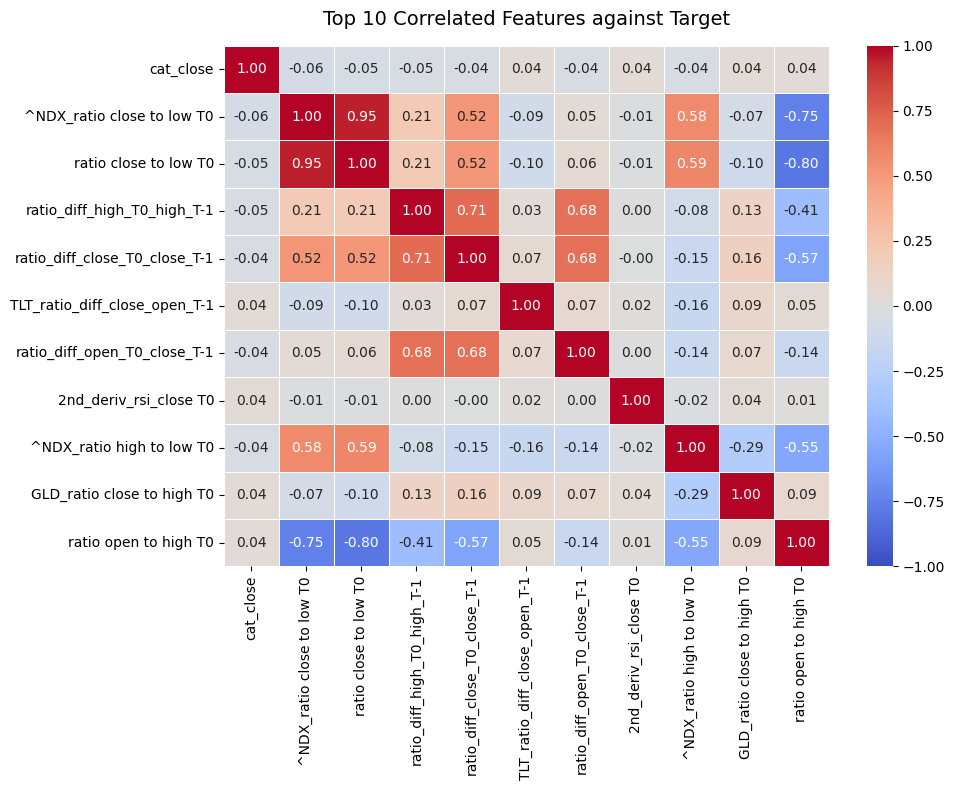

In [ ]:
# Check Correlation of features
df_corr = pd.concat([X_train, y_train], axis=1)
target_col = 'cat_close'

# Calculate the full correlation matrix
corr_matrix = df_corr.corr()

# Isolate correlation with target, drop the target itself, and take absolute values
target_corr = corr_matrix[target_col].drop(target_col).abs()

# Sort descending and grab the top 10 feature names
top_10_features = target_corr.sort_values(ascending=False).head(10).index.tolist()

columns_to_plot = [target_col] + top_10_features
top_corr_matrix = df_corr[columns_to_plot].corr()

plt.figure(figsize=(10, 8))

# Create the heatmap using Seaborn
sns.heatmap(
    top_corr_matrix,
    annot=True,             # Write numbers inside the boxes
    cmap='coolwarm',        # Blue for negative, Red for positive correlation
    fmt=".2f",              # Round values to 2 decimal places
    linewidths=0.5,         # Put subtle lines between grid squares
    vmin=-1, vmax=1         # Lock color bar boundaries to standard correlation range
)

plt.title('Top 10 Correlated Features against Target', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# Train XGB Classifier model

model = XGBClassifier(random_state=42
#    n_estimators=100, learning_rate=0.1, max_depth=5,random_state=42
)

# Fit the model
model.fit(X_train, y_train)

# Make train predictions
predictions = model.predict(X_test)
predicted_proba = model.predict_proba(X_test)[:, 1]

print('---Test Data---')
print(y_test.value_counts())
print(f'Accuracy Score : {accuracy_score(y_test, predictions)}')
print(f'Precision Score : {precision_score(y_test, predictions)}')
print(f'Recall Score : {recall_score(y_test, predictions)}')
print('--- Confusion Matrix ---')
print(confusion_matrix(y_test, predictions))
print('--- Classification Report ---')
print(classification_report(y_test, predictions, target_names=["Down", "Up"]))


---Test Data---
cat_close
1    68
0    56
Name: count, dtype: int64
Accuracy Score : 0.5403225806451613
Precision Score : 0.5662650602409639
Recall Score : 0.6911764705882353
--- Confusion Matrix ---
[[20 36]
 [21 47]]
--- Classification Report ---
              precision    recall  f1-score   support

        Down       0.49      0.36      0.41        56
          Up       0.57      0.69      0.62        68

    accuracy                           0.54       124
   macro avg       0.53      0.52      0.52       124
weighted avg       0.53      0.54      0.53       124



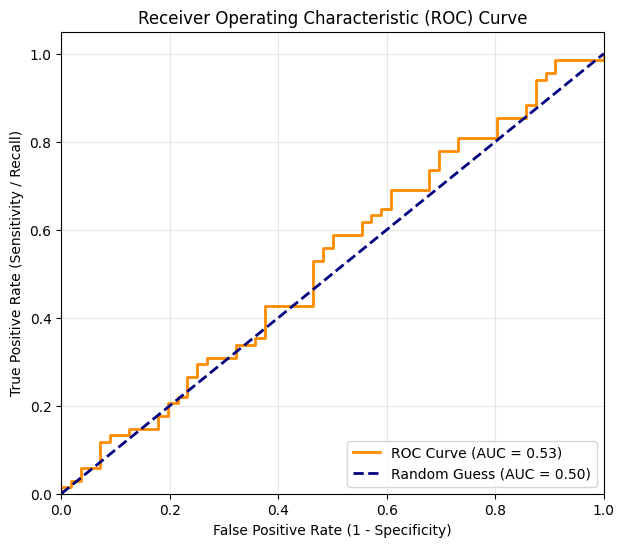

In [ ]:
# Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, predicted_proba)
auc_score = roc_auc_score(y_test, predicted_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

Match
1    72
0    49
Name: count, dtype: int64


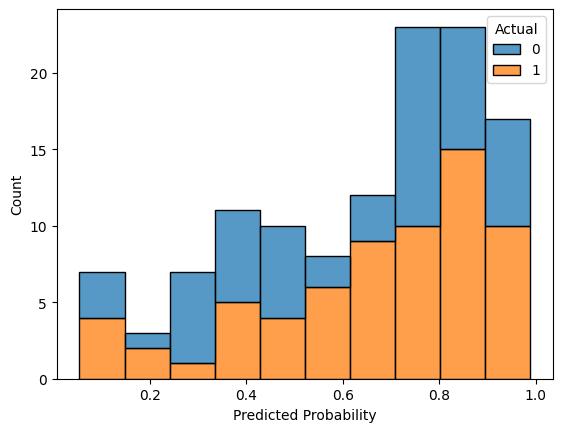

In [ ]:
# Create dataframe to plot histogram of predicted probability
df_pred = pd.DataFrame({
    'Date': test_date,
    'Actual': y_test,
    'Predicted': predictions,
    'Predicted Probability': predicted_proba})

df_pred['Match'] = np.where(df_pred['Actual'] == df_pred['Predicted'],1,0)
print(df_pred['Match'].value_counts())

# Assess the predicted probability distribution
sns.histplot(data=df_pred, x='Predicted Probability', hue='Actual', bins= 10, multiple='stack')
plt.show()

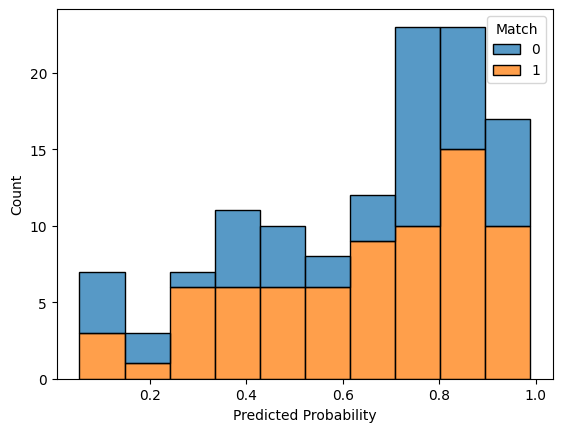

In [ ]:
# Assess the predicted probability distribution
sns.histplot(data=df_pred, x='Predicted Probability', hue='Match', bins= 10, multiple='stack')
plt.show()

In [ ]:
# Examining a a threshold point
t = 0.8
df_pred[df_pred['Predicted Probability'] >= t]['Match'].value_counts()

,count
Match,
1,25
0,15


In [ ]:
# Computed win rates and estimated earnings
r = np.arange(0.1, 1, 0.1)
win = []
lose = []
for i in np.arange(0.1, 1, 0.1):
  w = len(df_pred[(df_pred['Predicted Probability'] >= i) & (df_pred['Match'] == 1)])
  d = len(df_pred[(df_pred['Predicted Probability'] >= i) & (df_pred['Match'] == 0)])
  win.append(w)
  lose.append(d)

df_win_lose = pd.DataFrame({'prediction_threshold' : np.arange(0.1, 1, 0.1), 'Wins' : win, 'Lose' : lose})
df_win_lose['total'] = df_win_lose['Wins'] + df_win_lose['Lose']
df_win_lose['win_rate'] = df_win_lose['Wins'] / df_win_lose['total']
df_win_lose['estimated_earnings'] = round(df_win_lose['Wins'] * 50 - df_win_lose['Lose'] * 400, 0)
df_win_lose

,prediction_threshold,Wins,Lose,total,win_rate,estimated_earnings
0,0.1,70,49,119,0.588235,-16100
1,0.2,68,43,111,0.612613,-13800
2,0.3,64,43,107,0.598131,-14000
3,0.4,56,38,94,0.595745,-12400
4,0.5,51,34,85,0.600000,-11050
5,0.6,44,31,75,0.586667,-10200
6,0.7,35,28,63,0.555556,-9450
7,0.8,25,15,40,0.625000,-4750
8,0.9,10,7,17,0.588235,-2300


In [ ]:
# Compute sensitivity analysis of estimated earnings
for i in np.arange(50, 110, 10):
  df_win_lose[f'earnings_if_spread={i}'] = round(df_win_lose['Wins'] * i - df_win_lose['Lose'] * 400,0)
df_win_lose

,prediction_threshold,Wins,Lose,total,win_rate,estimated_earnings,earnings_if_spread=50,earnings_if_spread=60,earnings_if_spread=70,earnings_if_spread=80,earnings_if_spread=90,earnings_if_spread=100
0,0.1,70,49,119,0.588235,-16100,-16100,-15400,-14700,-14000,-13300,-12600
1,0.2,68,43,111,0.612613,-13800,-13800,-13120,-12440,-11760,-11080,-10400
2,0.3,64,43,107,0.598131,-14000,-14000,-13360,-12720,-12080,-11440,-10800
3,0.4,56,38,94,0.595745,-12400,-12400,-11840,-11280,-10720,-10160,-9600
4,0.5,51,34,85,0.600000,-11050,-11050,-10540,-10030,-9520,-9010,-8500
5,0.6,44,31,75,0.586667,-10200,-10200,-9760,-9320,-8880,-8440,-8000
6,0.7,35,28,63,0.555556,-9450,-9450,-9100,-8750,-8400,-8050,-7700
7,0.8,25,15,40,0.625000,-4750,-4750,-4500,-4250,-4000,-3750,-3500
8,0.9,10,7,17,0.588235,-2300,-2300,-2200,-2100,-2000,-1900,-1800


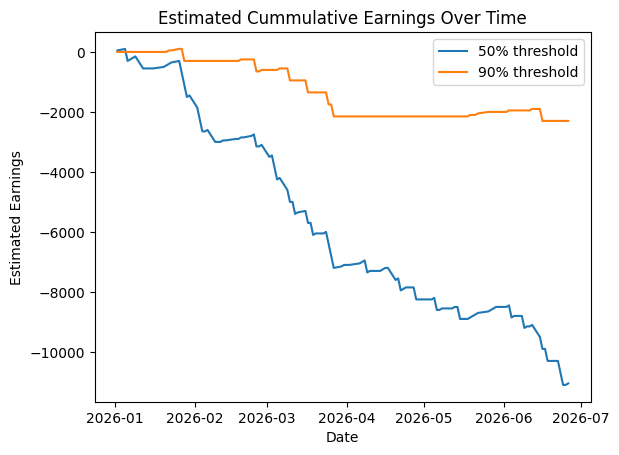

In [ ]:
# Equity Curve
def earnings_computation(row,spread,probability_threshold):
  if row['Predicted Probability'] >= probability_threshold:
    if row['Match'] == 1:
      earnings = spread
    else:
      earnings = -400
  else:
    earnings = 0
  return earnings

for i in [0.5, 0.9]:
  df_pred[f'earnings_at_threshold_{i}'] = df_pred.apply(lambda row: earnings_computation(row, 50, i), axis=1)
  df_pred[f'cummulative_earnings_at_threshold_{i}'] = df_pred[f'earnings_at_threshold_{i}'].cumsum()

sns.lineplot(x=df_pred['Date'], y=df_pred['cummulative_earnings_at_threshold_0.5'], label='50% threshold')
sns.lineplot(x=df_pred['Date'], y=df_pred['cummulative_earnings_at_threshold_0.9'], label='90% threshold')
plt.ylabel('Estimated Earnings')
plt.title("Estimated Cummulative Earnings Over Time")
plt.show()

In [ ]:
# Reverse calculate the required win rate
def calculate_breakeven_win_rate(win_payout, lose_penalty):
    """
    Calculates the exact win rate required to break even.

    Parameters:
    - win_payout (float): Positive amount gained on a win.
    - lose_penalty (float): Positive or negative amount lost on a loss.
    """
    # Ensure lose_penalty is positive for the formula calculation
    lose_penalty = abs(lose_penalty)

    # Formula derived from Expected Value = 0
    breakeven_rate = lose_penalty / (win_payout + lose_penalty)

    return breakeven_rate

# --- Calculate for your specific scenario ---
rounds = 100
win_reward = 50
loss_cost = -400

required_rate = calculate_breakeven_win_rate(win_reward, loss_cost)

print(f"Minimum Win Rate Required: {required_rate:.2%}")
print(f"Out of {rounds} rounds, you must win at least: {np.ceil(required_rate * rounds):.0f} rounds")

Minimum Win Rate Required: 88.89%
Out of 100 rounds, you must win at least: 89 rounds


In [ ]:
# Analysis of win rate for different level of win reward
l = []
for i in np.arange(50,110,10):
  l.append(calculate_breakeven_win_rate(i, loss_cost))

df_win_rate = pd.DataFrame({'Credit Spread' : np.arange(50,110,10), 'Win Rate Required for breakeven' : l})
df_win_rate

,Credit Spread,Win Rate Required for breakeven
0,50,0.888889
1,60,0.869565
2,70,0.851064
3,80,0.833333
4,90,0.816327
5,100,0.800000


In [ ]:
# List XGB Model feature importance

importances = model.feature_importances_

for name, score in dict(sorted(zip(X_train.columns, importances), key=lambda item: item[1], reverse=True)).items():
    print(f"{name}: {score:.4f}")

bb_20_period_2_std_open_to_lower: 0.0276
ratio sma_5_10 T0: 0.0152
bb_10_period_2_std_high_to_upper: 0.0124
SHY_ratio_diff_close_open_T0: 0.0103
ratio open to ema_20 T0: 0.0101
bb_10_period_2_std_low_to_upper: 0.0100
bb_10_period_4_std_close_to_lower: 0.0100
bb_20_period_3_std_close_to_upper: 0.0098
bb_10_period_2_std_close_to_lower: 0.0094
ratio close to open T0: 0.0088
VXX_ratio_diff_close_open_T0: 0.0087
ratio ema_10_20 T0: 0.0084
bb_10_period_4_std_close_to_upper: 0.0083
day_Tuesday: 0.0083
bb_5_period_3_std_low_to_upper: 0.0078
TLT_ratio open to high T0: 0.0078
ratio low to sma_10 T0: 0.0076
DX-Y.NYB_ratio_diff_close_open_T0: 0.0073
bb_5_period_3_std_open_to_lower: 0.0073
1st_deriv_rsi_close T0: 0.0073
bb_20_period_2_std_close_to_lower: 0.0073
ratio close to high T0: 0.0072
bb_10_period_4_std_high_to_upper: 0.0070
ratio sma_10_20 T0: 0.0070
ratio low to ema_20 T0: 0.0070
DX-Y.NYB_ratio open to low T0: 0.0070
bb_20_period_2_std_high_to_lower: 0.0069
VXX_ratio open to high T0: 0.006

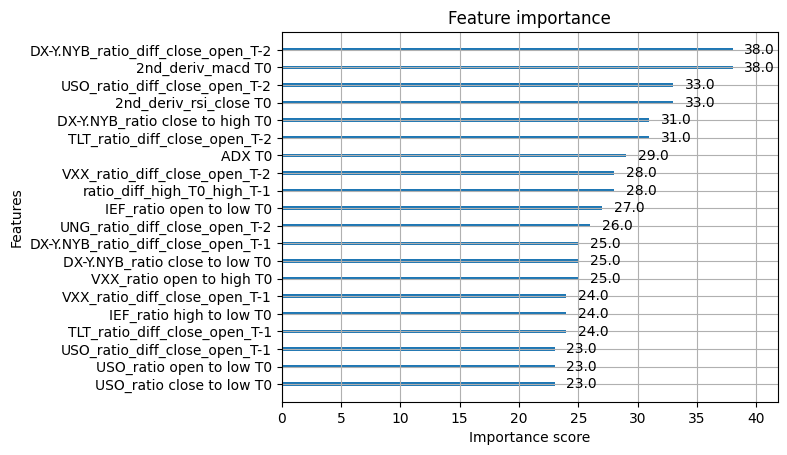

In [ ]:
# Plot feature importance
xgb.plot_importance(model, max_num_features=20)
plt.show()

In [ ]:
# 1 timestep forward prediction
if np.busday_offset(list_date.iloc[-1].date(), 1, roll="forward") < current_date:
  predicted_date = current_date
else:
  predicted_date = np.busday_offset(list_date.iloc[-1].date(), 1, roll="forward")

print(f'Previous date : {list_date.iloc[-1].date()}')
print(f'Predicted date : {predicted_date}')

print(model.predict(df_predict))
print(model.predict_proba(df_predict))

Previous date : 2026-07-02
Predicted date : 2026-07-03
[1]
[[0.14362097 0.85637903]]
